In [29]:
from langgraph.graph import StateGraph , END 
from typing import TypedDict , Annotated , List
from langchain_core.messages import  HumanMessage , AnyMessage , SystemMessage , AIMessage
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langgraph.prebuilt import create_react_agent
from dotenv import load_dotenv
import os
import base64
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from langchain.prompts import PromptTemplate
from operator import add

In [30]:
load_dotenv()

True

In [31]:
llm = ChatGoogleGenerativeAI(model=os.getenv("GOOGLE_MODEL"))
image_llm = ChatGoogleGenerativeAI(model="models/gemini-2.0-flash-preview-image-generation")

In [32]:
class agentState(TypedDict):
    query : str
    messages : Annotated[list[AnyMessage], add_messages] 
    agent_used : Annotated[list[str] , add]
    user_id : str
    human_feedback: Annotated[List[str] , add_messages]

In [33]:
router_prompt_template = """You are a multi-agent router responsible for selecting the best agent to handle the incoming user query. Choose the most suitable agent from the following options based on the task described in the query:

Available Agents:
- web_agent: Ideal for retrieving fresh, factual, or real-time information from the internet.
- llm_agent: Suitable for generating, transforming, or understanding text without needing live data.
- image_agent: Appropriate for generating visual content, such as illustrations, diagrams, or concept art.

Routing Logic:
1. If the query explicitly asks for an image, drawing, or visual representation, route to **image_gen_agent**.
2. If the query requests recent news, live events, or real-world facts, route to **web_search_agent**.
3. For all other cases, including creative writing, summarization, or general knowledge, route to **llm_search_agent**.

User Query:
{query}

Output Format:
Return only the most suitable agent name. If no agent is clearly suitable, default to **llm_agent**.
"""

router_prompt = PromptTemplate(template=router_prompt_template, input_variables=["query"])

In [34]:


from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate(
    input_variables=["feedback" , "query" , "messages"] , 
    template="""
    whenever the question looks like incomplete or need clarity 
    chat history : {messages} ,
    Humman Feedback : {feedback}
    generate a structure and well written response based on feedback and history 
    User query : {query}
    """
)



In [35]:
@tool
def tavily_search_tool_func(query: str) -> str:
    """Search the web for up-to-date information."""
    return TavilySearch(max_results=5, topic="general").invoke(query)

def web_agent(state:agentState) -> agentState:

    feedback = state["human_feedback"] if "human_feedback" in state else ["No feedback yey"]

    prompt_formated = prompt.format(
        feedback = feedback ,
        query = state["query"] ,
        messages = state["messages"],
    )
    web_search_agent = create_react_agent(model=llm, tools=[tavily_search_tool_func], name="web_expert" )
    
    result = web_search_agent.invoke({
                "messages": [
                    {
                        "role": "user",
                        "content": prompt_formated
                    }
                ]
            })

    # save_message(state["user_id"] , "user" , state["query"])
    # save_message(state["user_id"] , "ai" , result["messages"][-1].content)
    # state["messages"].append(result["messages"][-1])
    return {"messages" : [result["messages"][-1]]}


In [36]:
@tool
def llm_based_search_func(query: str) -> str:
    """Answer general knowledge queries using LLM."""
    return llm.invoke(query).content


def llm_agent(state:agentState) -> agentState:

    feedback = state["human_feedback"] if "human_feedback" in state else ["No feedback yey"]

    prompt_formated = prompt.format(
        feedback = feedback ,
        query = state["query"] ,
        messages = state["messages"],
    )

    llm_search_agent = create_react_agent(model=llm, tools=[llm_based_search_func], name="llm_expert")

    result = llm_search_agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": prompt_formated
                }
            ]
        })
    print("-----------------------------------")
    print(state["agent_used"])
    # save_message(state["user_id"], "user" , state["query"])
    # save_message(state["user_id"] , "assistant" , result["messages"][-1].content)
    return {"messages" : [result["messages"][-1].content]}
     


In [37]:
@tool
def image_gen_func(query: str) -> str:

    """Generate an image based on the description."""
    
    enhanced_query = (
        f"Create an image illustrating the following concept:\n{query}\n\n"
        "Only use English for any text in the image, and avoid unnecessary words."
    )
    response = image_llm.invoke(
        [HumanMessage(content=enhanced_query)],
        generation_config=dict(response_modalities=["TEXT", "IMAGE"])
    )

    # Extract image from response
    image_block = next(
        (block for block in response.content if isinstance(block, dict) and "image_url" in block),
        None
    )
    
    if not image_block:
        return "No image was generated."

    image_url = image_block["image_url"].get("url", "")
    if "base64" in image_url:
        base64_data = image_url.split(",")[-1]
        try:
            display(Image(data=base64.b64decode(base64_data), width=300))
        except Exception as e:
            return f"Failed to render image: {e}"
    else:
        return f"Image URL: {image_url}"  # fallback for URL-based image (if any)

    return "Image generated successfully."



def image_agent(state:agentState) -> agentState:

    image_gen_agent = create_react_agent(model=llm, tools=[image_gen_func], name="image_gen_expert" )
    feedback = state["human_feedback"] if "human_feedback" in state else ["No feedback yey"]

    prompt_formated = prompt.format(
        feedback = feedback ,
        query = state["query"] ,
        messages = state["messages"],
    )
    
    print(state)
    result = image_gen_agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": prompt_formated
                }
            ]
        })

    # save_message(state["user_id"], "user" , state["query"])
    # save_message(state["user_id"] , "assistant" ,result["messages"][-1].content)

    return {"messages": [result["messages"][-1]]} 



In [38]:
from langgraph.types import Command , interrupt

In [39]:
def humman_feedback(state:agentState)->agentState:
    generated_response = state["messages"][-1]

    # print("[generated response]" , generated_response)
    user_feedback = interrupt(
        {
            "generated_response" : generated_response,
            "message" : "Please provide feedback or done for finish"
        }
    )

    print(f"[human_node] Received human feedback: {user_feedback}")
    print("------------------------------------")
    print(state["agent_used"])
        # If user types "done", transition to END node
    if user_feedback.lower() == "done": 
        return Command(update={"human_feedback": state["human_feedback"] + ["Finalised"]}, goto="end_node")

    # Otherwise, update feedback and return to model for re-generation
    return Command(update={"human_feedback": state["human_feedback"] + [user_feedback]}, goto=state["agent_used"][-1])



In [40]:
def end_node(state: agentState): 
    """ Final node """
    print("\n[end_node] Process finished")
    print("Final Generated Post:", state["messages"][-1])
    print("Final Human Feedback", state["human_feedback"])
    print("Final agent used" , state["agent_used"])
    return {"generated_post": state["messages"], "human_feedback": state["human_feedback"] , "agent_used" : state["agent_used"]}

In [41]:
# image_gen_agent = create_react_agent(model=llm, tools=[image_gen_func], name="image_gen_expert" )
# 

In [42]:
# result = image_gen_agent.invoke({
#             "messages": [
#                 {
#                     "role": "user",
#                     "content": "generate image of cat and dog"
#                 }
#             ]
#         })

In [43]:
# result["messages"][-1].content

In [44]:
def supervisor_node(state:agentState)->agentState:
    router_chain = router_prompt | llm
    result = router_chain.invoke({"query" : state["query"]})
    print(result.content)

    return {"agent_used": [result.content]}

    

In [45]:
def should_continue(state : agentState) -> agentState:

    if state["agent_used"][-1] == "llm_agent":
        return "llm_agent"
    elif state["agent_used"][-1] == "web_agent":
        return "web_agent"
    elif state["agent_used"][-1] == "image_agent":
        return "image_agent"
    
    else:
        return "llm_agent"

In [46]:
graph = StateGraph(agentState)

In [47]:
graph.set_entry_point("routing agent")

graph.add_node("routing agent" , supervisor_node)
graph.add_node("ending" , end_node)
graph.add_node("humman_feedback" , humman_feedback)
graph.add_conditional_edges(
    "routing agent",
    should_continue,
    {
        "llm_agent" : "llm generation",
        "image_agent" : "image generation",
        "web_agent" : "web generation",

    }
)
graph.add_node("llm generation" , llm_agent)
graph.add_node("web generation" , web_agent)
graph.add_node("image generation" , image_agent)

graph.add_edge("web generation" , "humman_feedback")
graph.add_edge("llm generation" , "humman_feedback")
graph.add_edge("image generation" , "humman_feedback")

graph.add_edge("humman_feedback" , "ending")
graph.add_edge("ending" , END)

# graph.set_finish_point("routing agent")


In [48]:
from langgraph.checkpoint.memory import MemorySaver

In [49]:
checkpointer = MemorySaver()

In [50]:
app = graph.compile(checkpointer=checkpointer , debug=True)

In [51]:
thread_config = {"configurable": {
    "thread_id": "1234"
}}

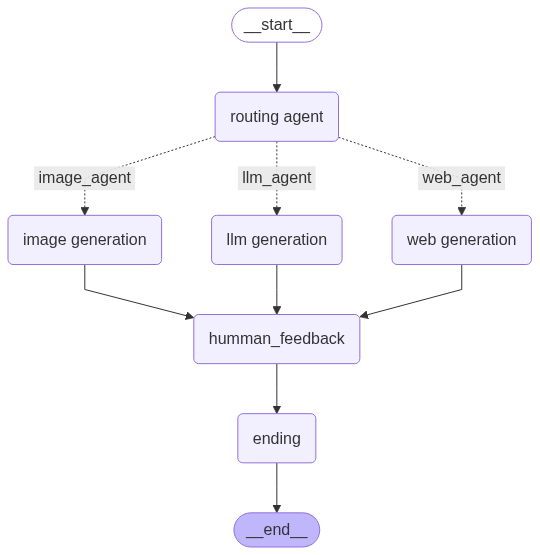

In [52]:
from IPython.display import display , Image
display(Image(app.get_graph().draw_mermaid_png()))

In [53]:
# retrieve_messages("123")

In [54]:
result = app.invoke({"query":" What is machine learning  and give me diagram?"  , "agent_used" : [] , "user_id" : "123"} , config=thread_config)

[-1:checkpoint] State at the end of step -1:
{'agent_used': [], 'human_feedback': [], 'messages': []}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'agent_used': [],
 'query': ' What is machine learning  and give me diagram?',
 'user_id': '123'}
[0:writes] Finished step 0 with writes to 3 channels:
- query -> ' What is machine learning  and give me diagram?'
- agent_used -> []
- user_id -> '123'
[0:checkpoint] State at the end of step 0:
{'agent_used': [],
 'human_feedback': [],
 'messages': [],
 'query': ' What is machine learning  and give me diagram?',
 'user_id': '123'}
[1:tasks] Starting 1 task for step 1:
- routing agent -> {'agent_used': [],
 'human_feedback': [],
 'messages': [],
 'query': ' What is machine learning  and give me diagram?',
 'user_id': '123'}
image_agent
[1:writes] Finished step 1 with writes to 1 channel:
- agent_used -> ['image_agent']
[1:checkpoint] State at the end of step 1:
{'agent_used': ['image_agent'],
 'human_feedback': [],
 'messages': [],
 'q

In [56]:
print(result)

{'query': ' What is machine learning  and give me diagram?', 'messages': [AIMessage(content="I can explain machine learning, but I can't create diagrams. Would you like me to explain what machine learning is?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, name='image_gen_expert', id='run--70796c5b-cb2f-492b-8bea-7eb659f7105e-0', usage_metadata={'input_tokens': 76, 'output_tokens': 26, 'total_tokens': 102, 'input_token_details': {'cache_read': 0}})], 'agent_used': ['image_agent'], 'user_id': '123', 'human_feedback': [], '__interrupt__': [Interrupt(value={'generated_response': AIMessage(content="I can explain machine learning, but I can't create diagrams. Would you like me to explain what machine learning is?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name':

In [57]:
import pprint
pprint.pprint(result)

{'__interrupt__': [Interrupt(value={'generated_response': AIMessage(content="I can explain machine learning, but I can't create diagrams. Would you like me to explain what machine learning is?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, name='image_gen_expert', id='run--70796c5b-cb2f-492b-8bea-7eb659f7105e-0', usage_metadata={'input_tokens': 76, 'output_tokens': 26, 'total_tokens': 102, 'input_token_details': {'cache_read': 0}}),
                                    'message': 'Please provide feedback or '
                                               'done for finish'},
                             resumable=True,
                             ns=['humman_feedback:8bb58a02-17a8-12a6-d10c-5a0d10c79e08'])],
 'agent_used': ['image_agent'],
 'human_feedback': [],
 'messages': [AIMessage(content="I can explain machine learning, but I can't create dia

In [ ]:
checkpointer.get(config=thread_config)

{'v': 3,
 'ts': '2025-06-02T08:15:03.651809+00:00',
 'id': '1f03f89a-f889-6540-8002-5424e7de112e',
 'channel_versions': {'__start__': '00000000000000000000000000000002.0.8352792904499975',
  'query': '00000000000000000000000000000002.0.08468707189273939',
  'messages': '00000000000000000000000000000004.0.8434547209940408',
  'agent_used': '00000000000000000000000000000003.0.2044660659840718',
  'user_id': '00000000000000000000000000000002.0.03148313599961938',
  'branch:to:routing agent': '00000000000000000000000000000003.0.26251584844634934',
  'branch:to:llm generation': '00000000000000000000000000000004.0.169695692709394',
  'branch:to:humman_feedback': '00000000000000000000000000000004.0.7132792561295694'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000001.0.425983266120354'},
  'routing agent': {'branch:to:routing agent': '00000000000000000000000000000002.0.518649536853546'},
  'llm generation': {'branch:to:llm generation': '0000000

In [ ]:
while user_feedback != "done":
    user_feedback = input("Provide feedback (or type 'done' when finished): ")

    if user_feedback.lower() != "done":
        resumed_result = app.invoke(
            Command(resume=user_feedback) , config=thread_config
        )
        import pprint
        pprint.pprint(resumed_result)


In [ ]:
import pprint

pprint.pprint(result)

{'__interrupt__': [Interrupt(value={'generated_response': HumanMessage(content='Given the repeated question about "What is machine learning?", I will provide a concise and well-structured response, summarizing the key aspects of machine learning.\n\nMachine learning (ML) is a subfield of artificial intelligence (AI) that focuses on enabling systems to learn from data and make predictions or decisions without being explicitly programmed. These systems improve their performance over time as they are exposed to more data.\n\n**Key Concepts:**\n\n*   **Learning from Data:** ML algorithms analyze data to identify patterns and relationships.\n*   **Algorithms:** These are sets of rules and statistical techniques that the system uses for learning.\n*   **Predictions/Decisions:** Trained models use what they\'ve learned to make predictions about new data or to make decisions.\n*   **Improvement Over Time:** Models refine their understanding and improve accuracy with more data through feedback 